# Fresnel propagation verification with `optics_simulator.fresnel`

This notebook is a tutorial-style physics sanity check for the `optics_simulator.fresnel`
module. It deliberately imports the propagation routines from the repository instead of
redefining them locally.

The goal is to verify:

1. plane waves and tilted plane waves behave as expected;
2. FFT/Fraunhofer PSFs from a finite circular aperture match the analytic Airy pattern;
3. one-step Fresnel propagation to the far field matches the same Airy pattern when expressed in screen coordinates;
4. an ideal thin lens focal plane matches both the analytic Airy pattern and explicit lens + Fresnel propagation;
5. energy is conserved under the propagation conventions used in the module.

Run this notebook from the repository root, or make sure the repository root is on `PYTHONPATH`.

In [ ]:
from pathlib import Path
import sys

# Make the notebook robust if opened from notebooks/.
cwd = Path.cwd()
if (cwd / "optics_simulator").exists():
    repo_root = cwd
elif (cwd.parent / "optics_simulator").exists():
    repo_root = cwd.parent
else:
    repo_root = cwd

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root guess:", repo_root)

Repository root guess: /home/bbarrer/Documents/ULTIMATE/repositories/mq_glao_testbench_sim/optics_simulator/examples


In [6]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import j1

# Make the notebook robust when launched from notebooks/ or examples/.
cwd = Path.cwd()
candidate_roots = [
    cwd,
    cwd.parent,
    cwd.parent.parent,
]
for root in candidate_roots:
    if (root / "optics_simulator").exists():
        sys.path.insert(0, str(root))
        REPO_ROOT = root
        break
else:
    REPO_ROOT = cwd

from optics_simulator import fresnel

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["image.origin"] = "lower"

## Local helper functions

These helpers are for diagnostics and plotting only. The actual propagation,
FFT PSF generation, apertures, and lens/focal-plane transforms come from
`optics_simulator.fresnel`.

In [7]:
def airy_intensity_lambda_over_d(r_ld):
    """
    Analytic circular-aperture Airy intensity.

    r_ld is radius in units of lambda/D.

    I(r) = [2 J1(pi r) / (pi r)]^2

    The first zero occurs at r = 3.8317/pi ~= 1.22 lambda/D.
    """
    r_ld = np.asarray(r_ld, dtype=float)
    x = np.pi * r_ld
    out = np.ones_like(x)
    nz = np.abs(x) > 1e-12
    out[nz] = (2.0 * j1(x[nz]) / x[nz]) ** 2
    return out


def airy_intensity_screen_radius(r_m, wavelength, z_or_f, diameter):
    """
    Analytic Airy intensity as a function of physical radius in a screen/focal plane.

    r_ld = r / (lambda * z_or_f / D)
    """
    r_ld = r_m / (wavelength * z_or_f / diameter)
    return airy_intensity_lambda_over_d(r_ld)


def radial_profile(image, x, y, nbins=500, r_max=None, centre=None):
    """
    Azimuthal radial profile of image on coordinates x,y.

    x and y may be 2D coordinate grids.
    """
    image = np.asarray(image, dtype=float)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if centre is None:
        yp, xp = np.unravel_index(np.nanargmax(image), image.shape)
        x0 = x[yp, xp]
        y0 = y[yp, xp]
    else:
        x0, y0 = centre

    r = np.sqrt((x - x0) ** 2 + (y - y0) ** 2)

    if r_max is None:
        r_max = np.nanmax(r)

    bins = np.linspace(0.0, r_max, nbins + 1)
    centres = 0.5 * (bins[:-1] + bins[1:])
    prof = np.full(nbins, np.nan)

    for i in range(nbins):
        m = (r >= bins[i]) & (r < bins[i + 1])
        if np.any(m):
            prof[i] = np.nanmean(image[m])

    return centres, prof


def normalise_peak(image):
    image = np.asarray(image, dtype=float)
    peak = np.nanmax(image)
    if peak > 0:
        return image / peak
    return image


def relative_l2(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    good = np.isfinite(a) & np.isfinite(b)
    if not np.any(good):
        return np.nan
    denom = np.linalg.norm(b[good])
    if denom == 0:
        return np.nan
    return np.linalg.norm(a[good] - b[good]) / denom


def find_first_radial_minimum(r, profile, expected, window=(0.6, 1.5)):
    """
    Find first minimum near expected radius.
    """
    r = np.asarray(r)
    p = np.asarray(profile)
    good = np.isfinite(r) & np.isfinite(p)
    r = r[good]
    p = p[good]

    if np.nanmax(p) > 0:
        p = p / np.nanmax(p)

    m = (r > window[0] * expected) & (r < window[1] * expected)
    if not np.any(m):
        return np.nan

    rw = r[m]
    pw = p[m]
    return float(rw[np.nanargmin(pw)])


def imshow_log(ax, image, extent=None, title="", floor=1e-6):
    image = normalise_peak(image)
    shown = np.log10(np.maximum(image, floor))
    im = ax.imshow(shown, extent=extent, cmap="magma", vmin=np.log10(floor), vmax=0)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="log10 peak-normalized intensity")
    return im

## Common parameters

We choose a small circular aperture so that all calculations run quickly, while
still producing enough pixels across the Airy disk to compare with the analytic
solution.

The computational window is deliberately wider than the aperture. This reduces
wrap-around and improves focal-plane sampling.

In [8]:
wavelength = 633e-9      # [m]
diameter = 1.0e-3        # aperture diameter [m]
radius = diameter / 2
N = 1024                 # grid size
window = 8.0e-3          # input-plane computational window [m]
dx = window / N
dy = dx

focal_length = 0.25      # [m]
far_z = 20.0             # [m]

print(f"lambda = {wavelength*1e9:.1f} nm")
print(f"D = {diameter*1e3:.3f} mm")
print(f"N = {N}, dx = {dx*1e6:.3f} um")
print(f"pixels across aperture ~= {diameter/dx:.1f}")

lambda = 633.0 nm
D = 1.000 mm
N = 1024, dx = 7.812 um
pixels across aperture ~= 128.0


In [9]:
X, Y = fresnel.make_coordinate_grid((N, N), dx, dy)
ap = fresnel.circular_aperture((N, N), dx=dx, dy=dy, radius=radius)
field_pupil = ap.astype(complex)

print("Input pupil energy:", fresnel.energy(field_pupil, dx, dy))
print("Pupil fill fraction:", np.mean(ap > 0))

Input pupil energy: 7.8448486328125e-07
Pupil fill fraction: 0.012257575988769531


## 1. Plane-wave sanity check

A uniform infinite plane wave remains uniform under propagation. On a finite
periodic FFT grid, a uniform array is exactly the zero spatial-frequency mode,
so the angular-spectrum propagator should preserve a flat amplitude. If the
global phase is disabled, the phase should also remain constant.

In [10]:
field0 = np.ones((256, 256), dtype=complex)
dx0 = 10e-6
z0 = 0.2

field1 = fresnel.angular_spectrum_propagate(
    field0,
    wavelength=wavelength,
    dx=dx0,
    z=z0,
    include_global_phase=False,
)

amp_err = np.max(np.abs(np.abs(field1) - 1.0))
energy0 = fresnel.energy(field0, dx0)
energy1 = fresnel.energy(field1, dx0)
rel_energy_err = abs(energy1 - energy0) / energy0

print("max amplitude error:", amp_err)
print("relative energy error:", rel_energy_err)

assert amp_err < 1e-12
assert rel_energy_err < 1e-12

max amplitude error: 0.0
relative energy error: 0.0


## 2. Tilted plane wave sanity check

A tilted plane wave has a phase ramp,

\[
E(x,y)=\exp[i k (\alpha_x x + \alpha_y y)] .
\]

Under free-space propagation it should remain a plane wave with the same
transverse spatial frequency. The angular-spectrum propagation changes only the
longitudinal phase factor.

In [ ]:


N = 256
dx = 10e-6
dy = dx
wavelength = 633e-9
z = 0.10

X, Y = fresnel.make_coordinate_grid((N, N), dx, dy)

# Choose an integer FFT mode.
m = 6
n = 3

fx0 = m / (N * dx)
fy0 = n / (N * dy)

# Equivalent physical small angles.
theta_x = np.arcsin(wavelength * fx0)
theta_y = np.arcsin(wavelength * fy0)

print("fx0 [cycles/m]:", fx0)
print("fy0 [cycles/m]:", fy0)
print("theta_x [mrad]:", theta_x * 1e3)
print("theta_y [mrad]:", theta_y * 1e3)

field_tilt = np.exp(1j * 2.0 * np.pi * (fx0 * X + fy0 * Y))

field_tilt_prop = fresnel.angular_spectrum_propagate(
    field_tilt,
    wavelength=wavelength,
    dx=dx,
    dy=dy,
    z=z,
    include_global_phase=False,
    bandlimit=True,
)

# Remove best-fit complex scalar phase/amplitude.
c = np.vdot(field_tilt, field_tilt_prop) / np.vdot(field_tilt, field_tilt)
err = np.linalg.norm(field_tilt_prop - c * field_tilt) / np.linalg.norm(field_tilt)

print("best-fit scalar:", c)
print("relative field error after removing scalar phase:", err)

assert err < 1e-10

fx0 [cycles/m]: 2343.75
fy0 [cycles/m]: 1171.875
theta_x [mrad]: 1.4835942942446458
theta_y [mrad]: 0.7417969430305302
best-fit scalar: (0.2038734020380446-0.9789972604361238j)
relative field error after removing scalar phase: 2.0281960971619613e-15


## 3. Fraunhofer FFT PSF of a finite circular aperture vs analytic Airy pattern

For a circular aperture, the far-field/Fraunhofer intensity should follow the
Airy pattern,

\[
I(\rho) = \left[\frac{2J_1(\pi \rho)}{\pi \rho}\right]^2,
\quad \rho = r/(\lambda/D).
\]

Here we use `fresnel.fft_psf()` and `fresnel.lambda_over_d_coordinates()`.

In [12]:
psf_fft = fresnel.fft_psf(field_pupil, pad_to=N, normalize="peak")
Xld, Yld = fresnel.lambda_over_d_coordinates(psf_fft.shape, dx_pupil=dx, pupil_diameter=diameter)

r_prof, p_prof = radial_profile(psf_fft, Xld, Yld, nbins=700, r_max=8.0, centre=(0.0, 0.0))
p_airy = airy_intensity_lambda_over_d(r_prof)

first_null_expected_ld = 1.22
first_null_meas_ld = find_first_radial_minimum(r_prof, p_prof, expected=first_null_expected_ld)

print("Expected first null [lambda/D]:", first_null_expected_ld)
print("Measured first null [lambda/D]:", first_null_meas_ld)
print("Relative first-null error:", abs(first_null_meas_ld - first_null_expected_ld) / first_null_expected_ld)

assert abs(first_null_meas_ld - first_null_expected_ld) / first_null_expected_ld < 0.08

Expected first null [lambda/D]: 1.22
Measured first null [lambda/D]: 1.2285714285714286
Relative first-null error: 0.007025761124121864


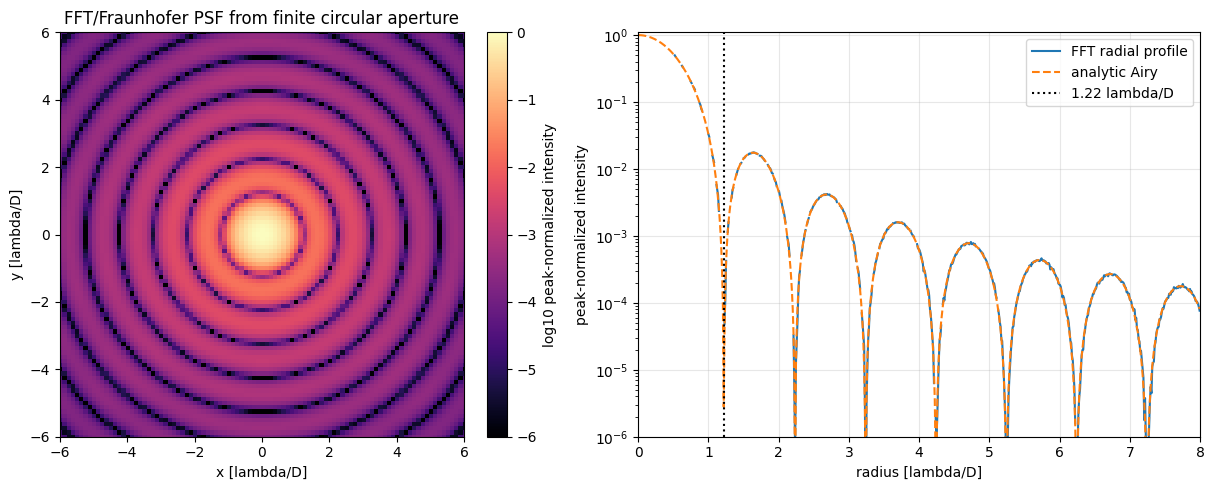

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

extent_ld = [Xld.min(), Xld.max(), Yld.min(), Yld.max()]
imshow_log(axes[0], psf_fft, extent=extent_ld, title="FFT/Fraunhofer PSF from finite circular aperture")
axes[0].set_xlim(-6, 6)
axes[0].set_ylim(-6, 6)
axes[0].set_xlabel("x [lambda/D]")
axes[0].set_ylabel("y [lambda/D]")

axes[1].semilogy(r_prof, normalise_peak(p_prof), label="FFT radial profile")
axes[1].semilogy(r_prof, p_airy, "--", label="analytic Airy")
axes[1].axvline(first_null_expected_ld, color="k", ls=":", label="1.22 lambda/D")
axes[1].set_xlim(0, 8)
axes[1].set_ylim(1e-6, 1.1)
axes[1].set_xlabel("radius [lambda/D]")
axes[1].set_ylabel("peak-normalized intensity")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Far-field finite-distance Fresnel propagation vs analytic Airy pattern

Fraunhofer propagation to a screen at finite distance \(z\) should give the same
Airy pattern when physical screen radius is converted by

\[
\rho = \frac{r}{\lambda z / D}.
\]

Here we use `fresnel.fresnel_one_step_propagate()`, which gives the physically
scaled output-plane sampling

\[
dx_\mathrm{out} = \frac{\lambda z}{N\,dx_\mathrm{in}}.
\]

In [14]:
field_far, dx_far, dy_far = fresnel.fresnel_one_step_propagate(
    field_pupil,
    wavelength=wavelength,
    dx=dx,
    dy=dy,
    z=far_z,
    include_global_phase=False,
)

I_far = normalise_peak(np.abs(field_far)**2)

Xfar, Yfar = fresnel.make_coordinate_grid(I_far.shape, dx_far, dy_far)

airy_scale_far = wavelength * far_z / diameter
first_null_expected_m = 1.22 * airy_scale_far

r_far, p_far = radial_profile(
    I_far,
    Xfar,
    Yfar,
    nbins=700,
    r_max=8.0 * airy_scale_far,
    centre=(0.0, 0.0),
)

p_airy_far = airy_intensity_screen_radius(r_far, wavelength, far_z, diameter)
first_null_meas_m = find_first_radial_minimum(r_far, p_far, expected=first_null_expected_m)

e0 = fresnel.energy(field_pupil, dx, dy)
e_far = fresnel.energy(field_far, dx_far, dy_far)

print("far-field dx_out [mm]:", dx_far * 1e3)
print("expected Airy first null [mm]:", first_null_expected_m * 1e3)
print("measured Airy first null [mm]:", first_null_meas_m * 1e3)
print("pixels per first-null radius:", first_null_expected_m / dx_far)
print("relative first-null error:", abs(first_null_meas_m - first_null_expected_m) / first_null_expected_m)
print("relative energy error:", abs(e_far - e0) / e0)

assert abs(e_far - e0) / e0 < 1e-12
assert abs(first_null_meas_m - first_null_expected_m) / first_null_expected_m < 0.08

far-field dx_out [mm]: 1.5825000000000002
expected Airy first null [mm]: 15.445200000000002
measured Airy first null [mm]: 15.553714285714287
pixels per first-null radius: 9.76
relative first-null error: 0.007025761124121804
relative energy error: 1.349664262021946e-16


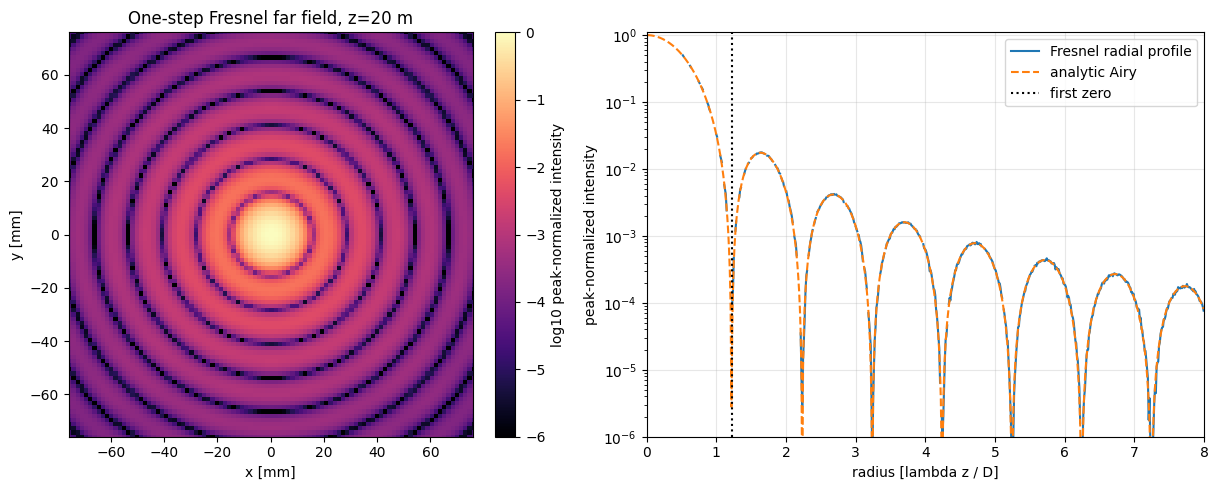

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

extent_far_mm = [Xfar.min()*1e3, Xfar.max()*1e3, Yfar.min()*1e3, Yfar.max()*1e3]
imshow_log(axes[0], I_far, extent=extent_far_mm, title=f"One-step Fresnel far field, z={far_z:g} m")
lim_mm = 6 * airy_scale_far * 1e3
axes[0].set_xlim(-lim_mm, lim_mm)
axes[0].set_ylim(-lim_mm, lim_mm)
axes[0].set_xlabel("x [mm]")
axes[0].set_ylabel("y [mm]")

axes[1].semilogy(r_far / airy_scale_far, normalise_peak(p_far), label="Fresnel radial profile")
axes[1].semilogy(r_far / airy_scale_far, p_airy_far, "--", label="analytic Airy")
axes[1].axvline(1.22, color="k", ls=":", label="first zero")
axes[1].set_xlim(0, 8)
axes[1].set_ylim(1e-6, 1.1)
axes[1].set_xlabel("radius [lambda z / D]")
axes[1].set_ylabel("peak-normalized intensity")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Thin-lens focal plane vs analytic Airy pattern

An ideal thin lens forms the Fraunhofer pattern in its focal plane. The natural
focal-plane sampling is

\[
dx_f = \frac{\lambda f}{N\,dx_\mathrm{pupil}}.
\]

Here we use `fresnel.lens_focal_plane_field()`, then compare the focal-plane
radial profile to the Airy pattern with

\[
\rho = \frac{r}{\lambda f / D}.
\]

In [16]:
field_focus, dx_focus, dy_focus = fresnel.lens_focal_plane_field(
    field_pupil,
    wavelength=wavelength,
    dx=dx,
    dy=dy,
    focal_length=focal_length,
    include_global_phase=False,
)

I_focus = normalise_peak(np.abs(field_focus)**2)

Xf, Yf = fresnel.make_coordinate_grid(I_focus.shape, dx_focus, dy_focus)

airy_scale_f = wavelength * focal_length / diameter
first_null_expected_f = 1.22 * airy_scale_f

r_focus, p_focus = radial_profile(
    I_focus,
    Xf,
    Yf,
    nbins=700,
    r_max=8.0 * airy_scale_f,
    centre=(0.0, 0.0),
)

p_airy_focus = airy_intensity_screen_radius(r_focus, wavelength, focal_length, diameter)
first_null_meas_f = find_first_radial_minimum(r_focus, p_focus, expected=first_null_expected_f)

e_focus = fresnel.energy(field_focus, dx_focus, dy_focus)

print("focal dx [um]:", dx_focus * 1e6)
print("expected Airy first null [um]:", first_null_expected_f * 1e6)
print("measured Airy first null [um]:", first_null_meas_f * 1e6)
print("pixels per first-null radius:", first_null_expected_f / dx_focus)
print("relative first-null error:", abs(first_null_meas_f - first_null_expected_f) / first_null_expected_f)
print("relative energy error:", abs(e_focus - e0) / e0)

assert abs(e_focus - e0) / e0 < 1e-12
assert abs(first_null_meas_f - first_null_expected_f) / first_null_expected_f < 0.08

focal dx [um]: 19.78125
expected Airy first null [um]: 193.065
measured Airy first null [um]: 194.42142857142858
pixels per first-null radius: 9.76
relative first-null error: 0.007025761124121833
relative energy error: 0.0


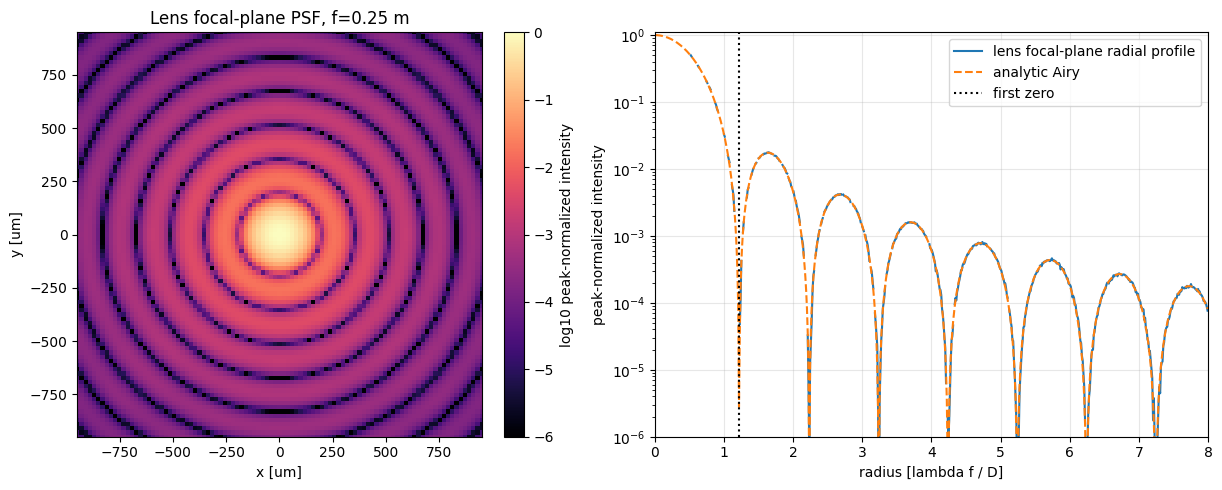

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

extent_f_um = [Xf.min()*1e6, Xf.max()*1e6, Yf.min()*1e6, Yf.max()*1e6]
imshow_log(axes[0], I_focus, extent=extent_f_um, title=f"Lens focal-plane PSF, f={focal_length:g} m")
lim_um = 6 * airy_scale_f * 1e6
axes[0].set_xlim(-lim_um, lim_um)
axes[0].set_ylim(-lim_um, lim_um)
axes[0].set_xlabel("x [um]")
axes[0].set_ylabel("y [um]")

axes[1].semilogy(r_focus / airy_scale_f, normalise_peak(p_focus), label="lens focal-plane radial profile")
axes[1].semilogy(r_focus / airy_scale_f, p_airy_focus, "--", label="analytic Airy")
axes[1].axvline(1.22, color="k", ls=":", label="first zero")
axes[1].set_xlim(0, 8)
axes[1].set_ylim(1e-6, 1.1)
axes[1].set_xlabel("radius [lambda f / D]")
axes[1].set_ylabel("peak-normalized intensity")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Thin lens + explicit one-step Fresnel propagation

This is a useful cross-check of the lens convention.

Two routes should produce the same focal-plane intensity:

1. direct focal-plane transform: `fresnel.lens_focal_plane_field(field, ..., f)`;
2. apply a thin lens phase, then propagate one focal length using
   `fresnel.fresnel_one_step_propagate`.

The complex fields may differ by a spatial phase factor depending on convention,
but the intensities should agree.

In [18]:
field_after_lens = fresnel.apply_thin_lens(
    field_pupil,
    wavelength=wavelength,
    dx=dx,
    dy=dy,
    focal_length=focal_length,
)

field_focus_explicit, dx_focus2, dy_focus2 = fresnel.fresnel_one_step_propagate(
    field_after_lens,
    wavelength=wavelength,
    dx=dx,
    dy=dy,
    z=focal_length,
    include_global_phase=False,
)

I_focus_explicit = normalise_peak(np.abs(field_focus_explicit)**2)

print("dx direct [um]:", dx_focus * 1e6)
print("dx lens+Fresnel [um]:", dx_focus2 * 1e6)

intensity_err = relative_l2(I_focus_explicit, I_focus)
print("relative L2 intensity error:", intensity_err)

assert np.isclose(dx_focus2, dx_focus)
assert intensity_err < 1e-10

dx direct [um]: 19.78125
dx lens+Fresnel [um]: 19.78125
relative L2 intensity error: 2.549331101018474e-16


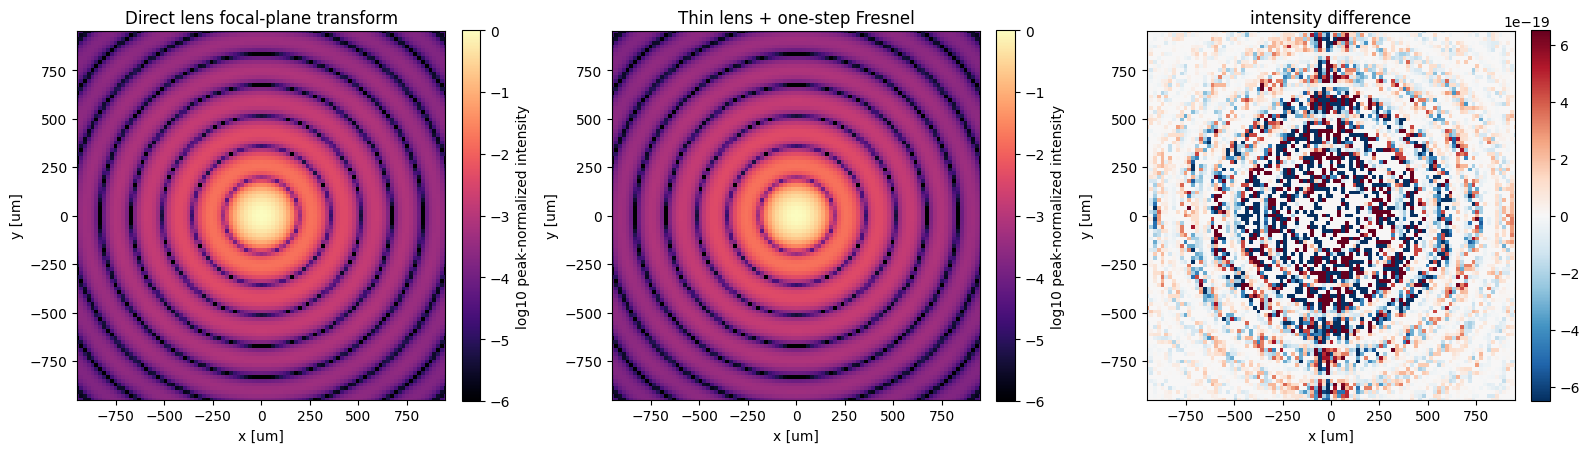

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

imshow_log(axes[0], I_focus, extent=extent_f_um, title="Direct lens focal-plane transform")
axes[0].set_xlim(-lim_um, lim_um)
axes[0].set_ylim(-lim_um, lim_um)
axes[0].set_xlabel("x [um]")
axes[0].set_ylabel("y [um]")

imshow_log(axes[1], I_focus_explicit, extent=extent_f_um, title="Thin lens + one-step Fresnel")
axes[1].set_xlim(-lim_um, lim_um)
axes[1].set_ylim(-lim_um, lim_um)
axes[1].set_xlabel("x [um]")
axes[1].set_ylabel("y [um]")

diff = I_focus_explicit - I_focus
v = np.nanpercentile(np.abs(diff), 99.9)
if not np.isfinite(v) or v <= 0:
    v = 1e-12
im = axes[2].imshow(diff, extent=extent_f_um, cmap="RdBu_r", vmin=-v, vmax=v)
axes[2].set_xlim(-lim_um, lim_um)
axes[2].set_ylim(-lim_um, lim_um)
axes[2].set_title("intensity difference")
axes[2].set_xlabel("x [um]")
axes[2].set_ylabel("y [um]")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 7. Near-field Fresnel diffraction from a finite circular aperture

The far-field tests above verify the Airy limit. The near field should not look
like an Airy pattern: it should show Fresnel diffraction structure in a plane
with the same physical sampling as the input grid when using the angular-spectrum
method.

This is not compared to a simple closed-form answer here; it is included as a
visual sanity check and to demonstrate why near-field and far-field samplings
should not be confused.

In [20]:
near_z = 0.05  # [m]

field_near = fresnel.angular_spectrum_propagate(
    field_pupil,
    wavelength=wavelength,
    dx=dx,
    dy=dy,
    z=near_z,
    include_global_phase=False,
)

I_near = normalise_peak(np.abs(field_near)**2)
Xn, Yn = X, Y

e_near = fresnel.energy(field_near, dx, dy)

print("Near-field Fresnel number D^2/(lambda z):", diameter**2 / (wavelength * near_z))
print("relative energy error:", abs(e_near - e0) / e0)

assert abs(e_near - e0) / e0 < 1e-12

Near-field Fresnel number D^2/(lambda z): 31.5955766192733
relative energy error: 4.0489927860658377e-16


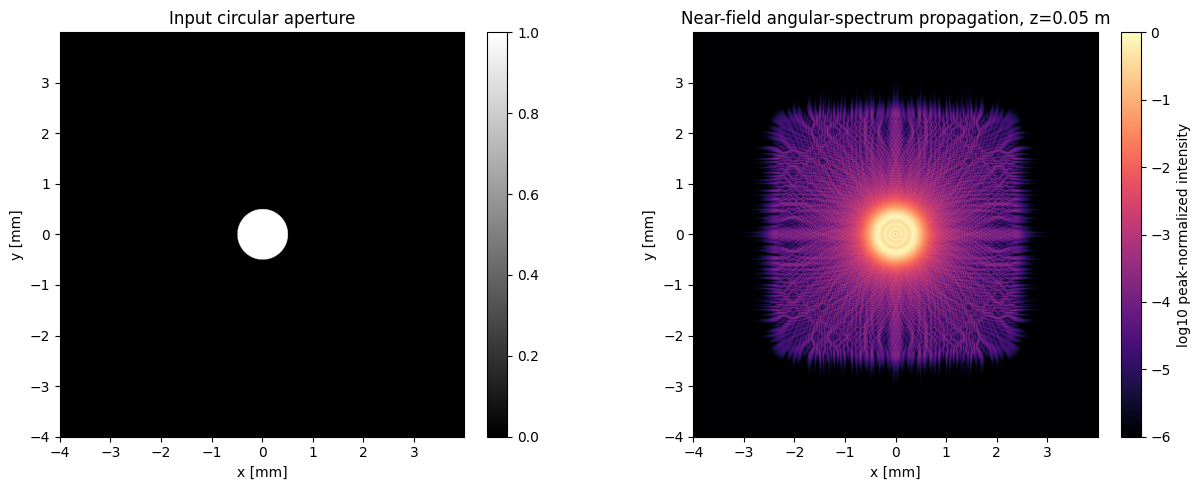

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

extent_mm_input = [X.min()*1e3, X.max()*1e3, Y.min()*1e3, Y.max()*1e3]

im0 = axes[0].imshow(ap, extent=extent_mm_input, cmap="gray")
axes[0].set_title("Input circular aperture")
axes[0].set_xlabel("x [mm]")
axes[0].set_ylabel("y [mm]")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

imshow_log(axes[1], I_near, extent=extent_mm_input, title=f"Near-field angular-spectrum propagation, z={near_z:g} m")
axes[1].set_xlabel("x [mm]")
axes[1].set_ylabel("y [mm]")

plt.tight_layout()
plt.show()

## Summary

These checks exercise the main physical regimes we care about:

- angular-spectrum propagation preserves plane waves and energy;
- FFT/Fraunhofer circular-aperture PSFs match the Airy pattern;
- one-step Fresnel propagation reaches the same Airy pattern in the far field with physical screen coordinates;
- ideal thin-lens focal-plane sampling matches the analytic Airy pattern;
- explicit thin-lens phase plus Fresnel propagation matches the direct focal-plane transform.

If all assertions pass, the core `optics_simulator.fresnel` functions are behaving consistently for the scalar diffraction cases used by the testbench simulations.